In [ ]:
!pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
!pip install ultralytics

In [ ]:
print(open("/content/drive/MyDrive/dataset_truba.yaml").read())

train: /content/drive/MyDrive/dataset_truba/images/train
val: /content/drive/MyDrive/dataset_truba/images/val

names:
  0: "truba"


In [ ]:
import os

print("dataset_truba:")
print(os.listdir("/content/drive/MyDrive/dataset_truba"))

print("\nimages:")
print(os.listdir("/content/drive/MyDrive/dataset_truba/images")[:20])

print("\nlabels:")
print(os.listdir("/content/drive/MyDrive/dataset_truba/labels")[:20])

dataset_truba:
['labels', 'images', 'notes.json', 'classes.txt']

images:
['00e05294-d1bc21d3843eaaf29d0df27797faa0e357de1f63.jpeg', '00cf85db-ironwill-steel-sia_1000211743_014_2000x1500.jpg', '7ec1a567-wgcugsgc19a2uk0y9vjmz4c28keh518r.JPG', '1a3e8449-stack-metal-pipes-corners-fittings-260nw-2699361895.webp', '969e1a34-476446759_1191906302380716_4064493094387039558_n.jpg', '48d08e43-0.jpg', '07b21ab7-ab06dfd0866a28c8193eeb2ad7c1182dc8a8dd1a.jpeg', 'd03f7490-ironwill-steel-sia_1000211743_015_2000x1500.jpg']

labels:
['1a3e8449-stack-metal-pipes-corners-fittings-260nw-2699361895.txt', 'd03f7490-ironwill-steel-sia_1000211743_015_2000x1500.txt', '969e1a34-476446759_1191906302380716_4064493094387039558_n.txt', '00cf85db-ironwill-steel-sia_1000211743_014_2000x1500.txt', '48d08e43-0.txt', '00e05294-d1bc21d3843eaaf29d0df27797faa0e357de1f63.txt', '7ec1a567-wgcugsgc19a2uk0y9vjmz4c28keh518r.txt', '07b21ab7-ab06dfd0866a28c8193eeb2ad7c1182dc8a8dd1a.txt']


In [ ]:
from pathlib import Path
import random
import shutil

# Исходный экспорт Label Studio
SRC = Path("/content/drive/MyDrive/dataset_truba")

# Новый датасет для YOLO
DST = Path("/content/drive/MyDrive/dataset_truba_split")

IMAGES = SRC / "images"
LABELS = SRC / "labels"

# Поддерживаемые расширения изображений
image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

# Получаем изображения
images = [
    p for p in IMAGES.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

print(f"Найдено изображений: {len(images)}")

# Проверяем соответствие image -> label
pairs = []

for image in images:
    label = LABELS / f"{image.stem}.txt"

    if label.exists():
        pairs.append((image, label))
    else:
        print(f"⚠ Нет разметки для: {image.name}")

print(f"Пар image + label: {len(pairs)}")

# Чтобы результат каждый раз был одинаковый
random.seed(42)
random.shuffle(pairs)

# 80% train / 20% validation
split_index = int(len(pairs) * 0.8)

train_pairs = pairs[:split_index]
val_pairs = pairs[split_index:]

print(f"Train: {len(train_pairs)}")
print(f"Val:   {len(val_pairs)}")

# Создаем структуру каталогов
for split in ("train", "val"):
    (DST / "images" / split).mkdir(parents=True, exist_ok=True)
    (DST / "labels" / split).mkdir(parents=True, exist_ok=True)


def copy_pairs(pairs, split):
    for image, label in pairs:

        shutil.copy2(
            image,
            DST / "images" / split / image.name
        )

        shutil.copy2(
            label,
            DST / "labels" / split / label.name
        )


copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")

print("\n✅ Датасет подготовлен:")
print(DST)

Найдено изображений: 8
Пар image + label: 8
Train: 6
Val:   2

✅ Датасет подготовлен:
/content/drive/MyDrive/dataset_truba_split


In [ ]:
yaml_text = """
path: /content/drive/MyDrive/dataset_truba_split

train: images/train
val: images/val

names:
  0: truba
"""

with open("/content/drive/MyDrive/dataset_truba.yaml", "w") as f:
    f.write(yaml_text)

print(open("/content/drive/MyDrive/dataset_truba.yaml").read())


path: /content/drive/MyDrive/dataset_truba_split

train: images/train
val: images/val

names:
  0: truba



In [ ]:
from pathlib import Path

root = Path("/content/drive/MyDrive/dataset_truba_split")

train_images = list((root / "images/train").glob("*"))
train_labels = list((root / "labels/train").glob("*.txt"))

val_images = list((root / "images/val").glob("*"))
val_labels = list((root / "labels/val").glob("*.txt"))

print("TRAIN")
print("images:", len(train_images))
print("labels:", len(train_labels))

print("\nVAL")
print("images:", len(val_images))
print("labels:", len(val_labels))

TRAIN
images: 6
labels: 6

VAL
images: 2
labels: 2


In [ ]:
print("\nПример label:")

label = train_labels[0]

print("Файл:", label.name)
print(label.read_text())


Пример label:
Файл: 1a3e8449-stack-metal-pipes-corners-fittings-260nw-2699361895.txt
0 0.3726361127935931 0.4015748031496063 0.0800861430782691 0.12073490813648291
0 0.46591291473181234 0.3366141732283465 0.06877986405545457 0.12204724409448822
0 0.38064472710142 0.5387139107611548 0.08291271283397272 0.12992125984251962
0 0.4706238643246517 0.5964566929133858 0.07631738340399749 0.12467191601049869
0 0.5568342418736119 0.624015748031496 0.07349081364829402 0.12467191601049869
0 0.5332794939094151 0.48556430446194226 0.07914395315970119 0.12598425196850394
0 0.57522712428966 0.26822540704870496 0.07254862372972604 0.11942257217847776
0 0.6444579043004239 0.597769028871391 0.03768759674271486 0.06692913385826771
0 0.5954640285348947 0.5229658792650919 0.04334073625412202 0.07480314960629919
0 0.702254844127711 0.5412108749694373 0.04645773802063141 0.06470899224302282
0 0.7562084762641753 0.4246250480546354 0.046457738020631384 0.06470899224302283
0 0.813077454802324 0.4166872669339632

In [ ]:
from ultralytics import YOLO

# Для твоего маленького датасета S гораздо разумнее X
model = YOLO("yolo11s.pt")

train_results = model.train(

    # Dataset
    data="/content/drive/MyDrive/dataset_truba.yaml",

    # Training
    epochs=200,
    patience=40,

    # КРИТИЧНО для мелких труб
    imgsz=1280,

    # 6 train-фотографий -> делаем маленькие batch
    batch=2,

    # КРИТИЧНО:
    # не даём Ultralytics накапливать градиенты до nominal batch=64
    nbs=2,

    # GPU
    device=0,
    amp=True,

    # Датасет у тебя микроскопический, легко помещается в RAM
    cache="ram",
    workers=2,

    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,

    # --------------------------------------------------
    # AUGMENTATION
    # --------------------------------------------------

    # Mosaic здесь скорее мешает:
    # трубы и без того очень маленькие
    mosaic=0.0,
    mixup=0.0,

    # Не уменьшаем объекты слишком агрессивно
    scale=0.15,

    # Лёгкие геометрические изменения
    translate=0.05,
    degrees=2.0,
    shear=0.0,
    perspective=0.0,

    # Горизонтальное отражение нормально
    fliplr=0.5,
    flipud=0.0,

    # Умеренные изменения освещения/цвета
    hsv_h=0.01,
    hsv_s=0.4,
    hsv_v=0.25,

    # Saving
    save=True,
    save_period=25,

    # Сохранять сразу на Google Drive
    project="/content/drive/MyDrive/yolo_runs",
    name="truba_yolo11s_1280",

    plots=True,
    seed=42,
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/dataset_truba.yaml, degrees=2.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.4, hsv_v=0.25, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=truba_yolo11s_1280, 


image 1/1 /content/drive/MyDrive/yolo_tests/test_truba.JPG: 896x1280 103 trubas, 34.7ms
Speed: 8.8ms preprocess, 34.7ms inference, 2.5ms postprocess per image at shape (1, 3, 896, 1280)

НАЙДЕНО ТРУБ: 103

Минимальный confidence: 0.266
Средний confidence:     0.755
Максимальный confidence:0.926


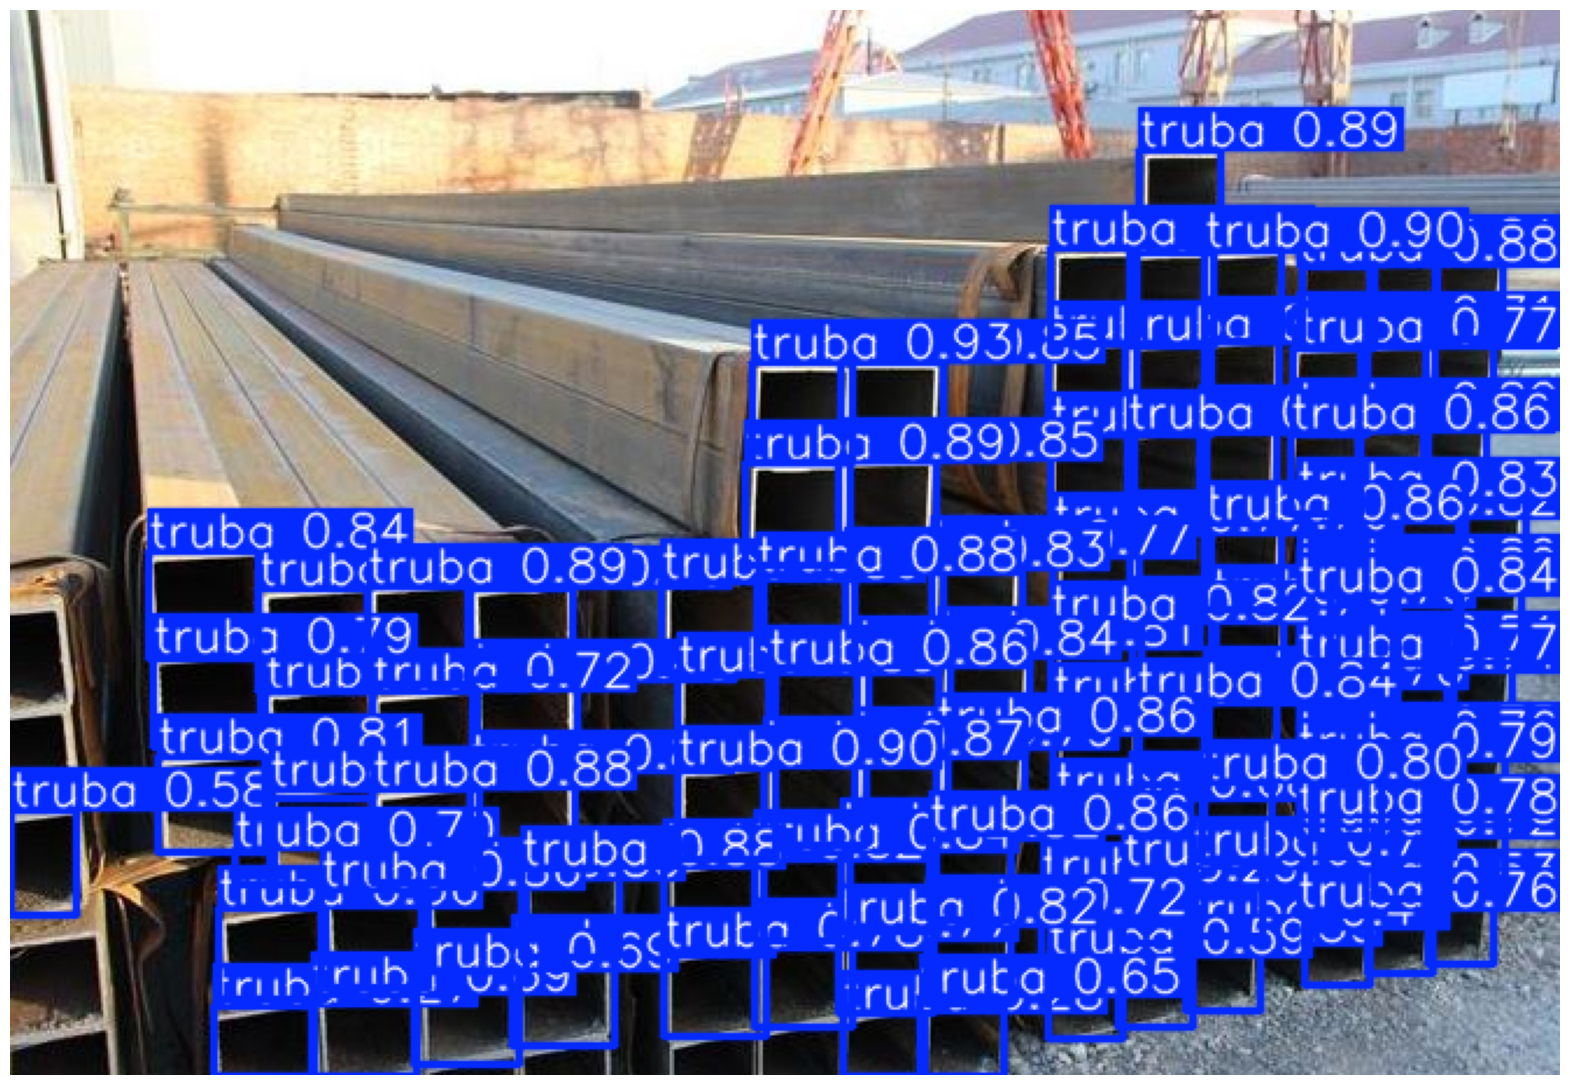

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Лучшая обученная модель
model = YOLO(
    "/content/drive/MyDrive/yolo_runs/truba_yolo11s_1280/weights/best.pt"
)

# Новая фотография
image_path = "/content/drive/MyDrive/yolo_tests/test_truba.JPG"

# Детекция
results = model.predict(
    source=image_path,
    imgsz=1280,
    conf=0.25,
    iou=0.5,
    max_det=1000,
    verbose=True
)

result = results[0]

# Сколько труб найдено
count = len(result.boxes)

print("\n============================")
print(f"НАЙДЕНО ТРУБ: {count}")
print("============================\n")

# Статистика confidence
if count > 0:
    confs = result.boxes.conf.cpu().numpy()

    print(f"Минимальный confidence: {confs.min():.3f}")
    print(f"Средний confidence:     {confs.mean():.3f}")
    print(f"Максимальный confidence:{confs.max():.3f}")

# Рисуем найденные трубы
annotated = result.plot()

annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(20, 15))
plt.imshow(annotated)
plt.axis("off")
plt.show()